[Course material - Sustain.Brussels - "Avdanced AI workflows with LLM" - 20/04/2026 - 22/04/2026](https://github.com/Yannael/gen-ai-sustain-brussels-2604).

# Defining and Using Tools in smolagents

In this hands-on session, you will learn how to define **tools** for an AI agent using the `smolagents` library, and how to wire them into a working agent. We will progressively build from a minimal example to more realistic use cases.

By the end of this notebook you will be able to:
- Define a tool using the `@tool` decorator
- Define a tool using the `Tool` class for more control
- Run a `CodeAgent` with your custom tools
- Inspect the agent's memory, system prompt, and reasoning steps
- Build tools that call external APIs, generate images, or search documents

---
## Prerequisites

Install the `smolagents` library. The `[mcp]` extra adds support for external tool servers.

In [ ]:
!pip install --quiet smolagents[mcp]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.7/155.7 kB 10.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
transformers 5.0.0 requires huggingface-hub<2.0,>=1.3.0, but you have huggingface-hub 0.36.2 which is incompatible.


---
## Part 1 — The `@tool` Decorator

The fastest way to expose a Python function as an agent tool is the `@tool` decorator. The decorator reads the **type hints** and **docstring** to build the tool's description automatically.

### 1.1 Defining a minimal tool

Three things make a valid `@tool` function:

| Requirement | Where it goes |
|---|---|
| Input types | Python type hints on the parameters |
| Return type | Python return type hint |
| Description | The function's docstring (first line = summary, `Args:` block = parameter descriptions) |

In [ ]:
from smolagents import tool

@tool
def get_weather(location: str) -> str:
    """
    Retrieves the current weather for a given location.

    Args:
        location: The city or place for which to fetch the weather.
    """
    # In a real tool, call a weather API here.
    return f"The weather in {location} is rainy with mild temperatures."

#### Exercise 1.1 — Inspect the generated schema

Run the cell below to see exactly what `smolagents` extracted from your function. This is what the agent model sees when it decides whether to call your tool.

**Questions to answer:**
- Where does `get_weather.description` come from in the source code above?
- What do you think happens if you remove the `-> str` return type hint and re-apply the decorator?

In [ ]:
print("name       :", get_weather.name)
print("description:", get_weather.description)
print("inputs     :", get_weather.inputs)

name       : get_weather
description: Retrieves the current weather for a given location.
inputs     : {'location': {'type': 'string', 'description': 'The city or place for which to fetch the weather.'}}


### 1.2 Running the tool with a CodeAgent

A `CodeAgent` uses the model to write and execute Python code that calls your tools. `verbosity_level=2` prints every reasoning step, which is useful while learning.

In [ ]:
from smolagents import InferenceClientModel, CodeAgent

# Point to a model on the Hugging Face Hub (inference runs on HF servers — no GPU needed)
model = InferenceClientModel("Qwen/Qwen3.5-9B", api_key="...")

# Create an agent and give it the tool
agent = CodeAgent(tools=[get_weather], model=model, verbosity_level=2)

# Ask a question — the agent will decide when and how to call the tool
result = agent.run("What is the weather like in Brussels today?")

print("\n=== Final answer ===")
print(result)

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ What is the weather like in Brussels today?                                                                     │
│                                                                                                                 │
╰─ InferenceClientModel - Qwen/Qwen3.5-9B ────────────────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Output message of the LLM: ────────────────────────────────────────────────────────────────────────────────────────
Thought: I need to get the weather information for Brussels. I can use the `get_weather` function which takes a    
location parameter.                                                                                                
<code>                                                                                                             
weather = get_weather(location="Brussels")                                                                         
print(weather)                                                                                                     

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  weather = get_weather(location="Brussels")                                                                       
  print(weather)                                                                                                   
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Execution logs:
The weather in Brussels is rainy with mild temperatures.

Out: None

...

Output message of the LLM: ────────────────────────────────────────────────────────────────────────────────────────
Thought: I have received the weather information for Brussels. The output shows that it is rainy with mild         
temperatures. I can now provide the final answer.                                                                  
<code>                                                                                                             
final_answer("Raining with mild temperatures")                                                                     

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  final_answer("Raining with mild temperatures")                                                                   
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer: Raining with mild temperatures

[Step 2: Duration 1.71 seconds| Input tokens: 4,509 | Output tokens: 176]


=== Final answer ===
Raining with mild temperatures


#### Exercise 1.2 — Change verbosity

Set `verbosity_level=0` in the cell above and run the agent again. What information disappears? Try `verbosity_level=1` as well. Write down what each level shows.

#### Exercise 1.3 — Two cities in one question

Change the query to `"Compare the weather in Brussels and in Amsterdam."` and run the agent. How many times does it call `get_weather`? Does it call the tool once or twice?

In [ ]:
# Your code here
# Ask a question — the agent will decide when and how to call the tool
result = agent.run("Compare the weather in Brussels and in Amsterdam.")

print("\n=== Final answer ===")
print(result)

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Compare the weather in Brussels and in Amsterdam.                                                               │
│                                                                                                                 │
╰─ InferenceClientModel - Qwen/Qwen3.5-9B ────────────────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Output message of the LLM: ────────────────────────────────────────────────────────────────────────────────────────
Thought: I need to get the weather information for both Brussels and Amsterdam using the `get_weather` tool, then  
compare them.                                                                                                      
<code>                                                                                                             
brussels_weather = get_weather(location="Brussels")                                                                
amsterdam_weather = get_weather(location="Amsterdam")                                                              
print(f"Brussels weather: {brussels_weather}")                                                                     
print(f"Amsterdam weather: {amsterdam_weather}")                                                                   

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  brussels_weather = get_weather(location="Brussels")                                                              
  amsterdam_weather = get_weather(location="Amsterdam")                                                            
  print(f"Brussels weather: {brussels_weather}")                                                                   
  print(f"Amsterdam weather: {amsterdam_weather}")                                                                 
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Execution logs:
Brussels weather: The weather in Brussels is rainy with mild temperatures.
Amsterdam weather: The weather in Amsterdam is rainy with mild temperatures.

Out: None

...

Output message of the LLM: ────────────────────────────────────────────────────────────────────────────────────────
Thought: I have retrieved the weather information for both Brussels and Amsterdam. Both cities have rainy weather  
with mild temperatures. I will now provide a final answer comparing these results.                                 
<code>                                                                                                             
final_answer("Both Brussels and Amsterdam have rainy weather with mild temperatures. The weather conditions in both
cities are similar.")                                                                                              

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  final_answer("Both Brussels and Amsterdam have rainy weather with mild temperatures. The weather conditions in   
  both cities are similar.")                                                                                       
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer: Both Brussels and Amsterdam have rainy weather with mild temperatures. The weather conditions in both
cities are similar.

[Step 2: Duration 2.06 seconds| Input tokens: 4,601 | Output tokens: 248]


=== Final answer ===
Both Brussels and Amsterdam have rainy weather with mild temperatures. The weather conditions in both cities are similar.


---
## Part 2 — Inspecting Agent Behaviour

After the agent runs, you can look inside its memory to understand what happened.

### 2.1 Conversation history

This shows the full turn-by-turn exchange: the user request, the model's reasoning, the tool call, the tool result, and the final answer.

In [ ]:
messages = agent.write_memory_to_messages()
for msg in messages:
    print(f"\n--- {msg.role} ---")
    print(msg.content)


--- MessageRole.SYSTEM ---
[{'type': 'text', 'text': 'You are an expert assistant who can solve any task using code blobs. You will be given a task to solve as best you can.\nTo do so, you have been given access to a list of tools: these tools are basically Python functions which you can call with code.\nTo solve the task, you must plan forward to proceed in a series of steps, in a cycle of Thought, Code, and Observation sequences.\n\nAt each step, in the \'Thought:\' sequence, you should first explain your reasoning towards solving the task and the tools that you want to use.\nThen in the Code sequence you should write the code in simple Python. The code sequence must be opened with \'<code>\', and closed with \'</code>\'.\nDuring each intermediate step, you can use \'print()\' to save whatever important information you will then need.\nThese print outputs will then appear in the \'Observation:\' field, which will be available as input for the next step.\nIn the end you have to retur

**Questions — answer in the cell below:**
- Which `role` in the message list contains the tool call?
- Which `role` contains the tool's return value?
- How many messages are there in total for a single-tool-call run?

In [ ]:
# Print the list of roles to help answer the questions above
print([msg.role for msg in messages])

### 2.2 System prompt

The system prompt explains to the model what it is, what tools it has, and how it should behave.

In [ ]:
print(messages[0].content[0]['text'])

You are an expert assistant who can solve any task using code blobs. You will be given a task to solve as best you can.
To do so, you have been given access to a list of tools: these tools are basically Python functions which you can call with code.
To solve the task, you must plan forward to proceed in a series of steps, in a cycle of Thought, Code, and Observation sequences.

At each step, in the 'Thought:' sequence, you should first explain your reasoning towards solving the task and the tools that you want to use.
Then in the Code sequence you should write the code in simple Python. The code sequence must be opened with '<code>', and closed with '</code>'.
During each intermediate step, you can use 'print()' to save whatever important information you will then need.
These print outputs will then appear in the 'Observation:' field, which will be available as input for the next step.
In the end you have to return a final answer using the `final_answer` tool.

Here are a few examples 

#### Exercise 2.1 — Find your tool in the system prompt

Search the printed text for the word `get_weather`. Where exactly does the model learn about your tool's name, description, and expected inputs?

---
## Part 3 — The `Tool` Class

The `@tool` decorator is convenient but limited. For tools that need **initialisation** (loading a model, opening a connection, reading a file), use the `Tool` class directly.

### 3.1 Anatomy of a Tool class

Every `Tool` subclass defines four class-level attributes:

| Attribute | Purpose |
|---|---|
| `name` | Identifier the agent uses to call the tool |
| `description` | Natural-language description shown to the model |
| `inputs` | Dict mapping parameter names to `{type, description}` |
| `output_type` | Type of the return value (`"string"`, `"image"`, …) |

Heavy setup (API clients, model loading) goes in `__init__`. The actual logic goes in `forward`.

In [ ]:
from smolagents import Tool

class GetWeatherTool(Tool):
    name = "get_weather"
    description = "Retrieves the current weather for a given location."
    inputs = {
        "location": {
            "type": "string",
            "description": "The city or place for which to fetch the weather."
        }
    }
    output_type = "string"

    def __init__(self):
        # Heavy setup goes here (API clients, loaded models, etc.)
        self.is_initialized = True

    def forward(self, location: str) -> str:
        # The actual tool logic
        return f"The weather in {location} is sunny with mild temperatures."

# Instantiate and use exactly like the decorator version
get_weather_tool = GetWeatherTool()

agent = CodeAgent(tools=[get_weather_tool], model=model, verbosity_level=2)
result = agent.run("What is the weather like in London?")
print(result)

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ What is the weather like in London?                                                                             │
│                                                                                                                 │
╰─ InferenceClientModel - Qwen/Qwen3.5-9B ────────────────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Output message of the LLM: ────────────────────────────────────────────────────────────────────────────────────────
Thought: I need to use the `get_weather` function to retrieve the current weather for London.                      
<code>                                                                                                             
weather = get_weather(location="London")                                                                           
print(weather)                                                                                                     

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  weather = get_weather(location="London")                                                                         
  print(weather)                                                                                                   
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Execution logs:
The weather in London is sunny with mild temperatures.

Out: None

...

Output message of the LLM: ────────────────────────────────────────────────────────────────────────────────────────
Thought: I have received the weather information for London from the previous code execution. The weather is sunny 
with mild temperatures. Now I need to provide the final answer.                                                    
<code>                                                                                                             
final_answer("The weather in London is sunny with mild temperatures.")                                             

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  final_answer("The weather in London is sunny with mild temperatures.")                                           
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer: The weather in London is sunny with mild temperatures.

[Step 2: Duration 1.96 seconds| Input tokens: 4,498 | Output tokens: 181]

The weather in London is sunny with mild temperatures.


#### Exercise 3.1 — Add a second parameter

Extend `GetWeatherTool` with a second input `unit` that accepts `"celsius"` or `"fahrenheit"`. Update `inputs` and `forward`, then ask the agent: `"What is the weather in Madrid in Fahrenheit?"`

Starter snippet for the new input:
```python
"unit": {
    "type": "string",
    "description": "Temperature unit, either 'celsius' or 'fahrenheit'."
}
```

In [ ]:
# Your code here
class GetWeatherTool(Tool):
    name = "get_weather"
    description = "Retrieves the current weather for a given location and temperature unit."
    inputs = {
        "location": {
            "type": "string",
            "description": "The city or place for which to fetch the weather."
        },
        "unit": {
            "type": "string",
            "description": "Temperature unit, either 'celsius' or 'fahrenheit'."
        }
    }
    output_type = "string"
    def __init__(self):
        # Heavy setup goes here (API clients, loaded models, etc.)
        self.is_initialized = True

    def forward(self, location: str, unit: str) -> str:
        # The actual tool logic
        if unit == "celsius":
            return f"The weather in {location} is sunny with mild temperatures in Celsius."
        elif unit == "fahrenheit":
            return f"The weather in {location} is sunny with mild temperatures in Fahrenheit."

get_weather_tool = GetWeatherTool()

agent = CodeAgent(tools=[get_weather_tool], model=model, verbosity_level=2)
result = agent.run("What is the weather in Madrid in Fahrenheit?")
print(result)

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ What is the weather in Madrid in Fahrenheit?                                                                    │
│                                                                                                                 │
╰─ InferenceClientModel - Qwen/Qwen3.5-9B ────────────────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Output message of the LLM: ────────────────────────────────────────────────────────────────────────────────────────
Thought: I need to get the weather in Madrid in Fahrenheit. I have access to the `get_weather` function that takes 
a location and a temperature unit. I'll call this function with location="Madrid" and unit="fahrenheit".           
                                                                                                                   
<code>                                                                                                             
weather = get_weather(location="Madrid", unit="fahrenheit")                                                        
print(weather)                                                                                                     

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  weather = get_weather(location="Madrid", unit="fahrenheit")                                                      
  print(weather)                                                                                                   
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Execution logs:
The weather in Madrid is sunny with mild temperatures in fahrenheit.

Out: None

...

Output message of the LLM: ────────────────────────────────────────────────────────────────────────────────────────
<code>                                                                                                             
final_answer("The weather in Madrid is sunny with mild temperatures in fahrenheit.")                               

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  final_answer("The weather in Madrid is sunny with mild temperatures in fahrenheit.")                             
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer: The weather in Madrid is sunny with mild temperatures in fahrenheit.

[Step 2: Duration 1.88 seconds| Input tokens: 4,589 | Output tokens: 256]

The weather in Madrid is sunny with mild temperatures in fahrenheit.


### 3.2 When to use class vs decorator

| Situation | Use |
|---|---|
| Simple, stateless function | `@tool` decorator |
| Needs setup (API client, ML model load, file read) | `Tool` class |
| Output is an image or other non-string type | `Tool` class (`output_type = "image"`) |
| You want to unit-test the tool independently | `Tool` class |

#### Exercise 3.2 — Write a tool from scratch

Using the `Tool` class, write a `WordCountTool` that accepts a `text: str` and returns a string like `"The text contains 9 words."`. Then create a `CodeAgent` with this tool and run:

```
"How many words are in: 'The quick brown fox jumps over the lazy dog'?"
```

Verify the answer matches `len(text.split())`.

In [ ]:
from smolagents import Tool

class WordCountTool(Tool):
    name = "word_count"
    description = "Counts the number of words in a given text and returns a formatted string."
    inputs = {
        "text": {
            "type": "string",
            "description": "The text for which to count the words."
        }
    }
    output_type = "string"

    def __init__(self):
        self.is_initialized = True

    def forward(self, text: str) -> str:
        words = text.split()
        return f"The text contains {len(words)} words."

In [ ]:
get_wordcount_tool = WordCountTool()

agent = CodeAgent(tools=[get_wordcount_tool], model=model, verbosity_level=2)
result = agent.run("How many words in this text : What is the weather in Madrid in Fahrenheit?")
print(result)

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ How many words in this text : What is the weather in Madrid in Fahrenheit?                                      │
│                                                                                                                 │
╰─ InferenceClientModel - Qwen/Qwen3.5-9B ────────────────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Output message of the LLM: ────────────────────────────────────────────────────────────────────────────────────────
Thought: I need to count the words in the given text. I have a `word_count` tool that can do this for me. I'll pass
the text to this tool.                                                                                             
                                                                                                                   
<code>                                                                                                             
text = "What is the weather in Madrid in Fahrenheit?"                                                              
result = word_count(text=text)                                                                                     
print(result)                                                                                                      

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  text = "What is the weather in Madrid in Fahrenheit?"                                                            
  result = word_count(text=text)                                                                                   
  print(result)                                                                                                    
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Execution logs:
The text contains 8 words.

Out: None

...

Output message of the LLM: ────────────────────────────────────────────────────────────────────────────────────────
Thought: The word_count tool has returned that the text contains 8 words. I now need to provide the final answer.  
                                                                                                                   
<code>                                                                                                             
final_answer(8)                                                                                                    

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  final_answer(8)                                                                                                  
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer: 8

[Step 2: Duration 1.32 seconds| Input tokens: 4,556 | Output tokens: 295]

8


---
## Part 4 — More Complex Tools

### 4.1 Image generation tool

A tool can return an `image` instead of a string. The agent can then display or save it.

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Generate a high-res photorealistic image of Brussels by night                                                   │
│                                                                                                                 │
╰─ InferenceClientModel - Qwen/Qwen3.5-9B ────────────────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  image = image_generator("high-res photorealistic image of Brussels by night, cityscape with illuminated          
  buildings, street lights, cobblestone streets, grand architecture, European city atmosphere, detailed and        
  realistic")                                                                                                      
  final_answer(image)                                                                                              
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer: <PIL.PngImagePlugin.PngImageFile image mode=RGB size=1024x1024 at 0x7DD1CE108560>

[Step 1: Duration 14.09 seconds| Input tokens: 2,201 | Output tokens: 206]

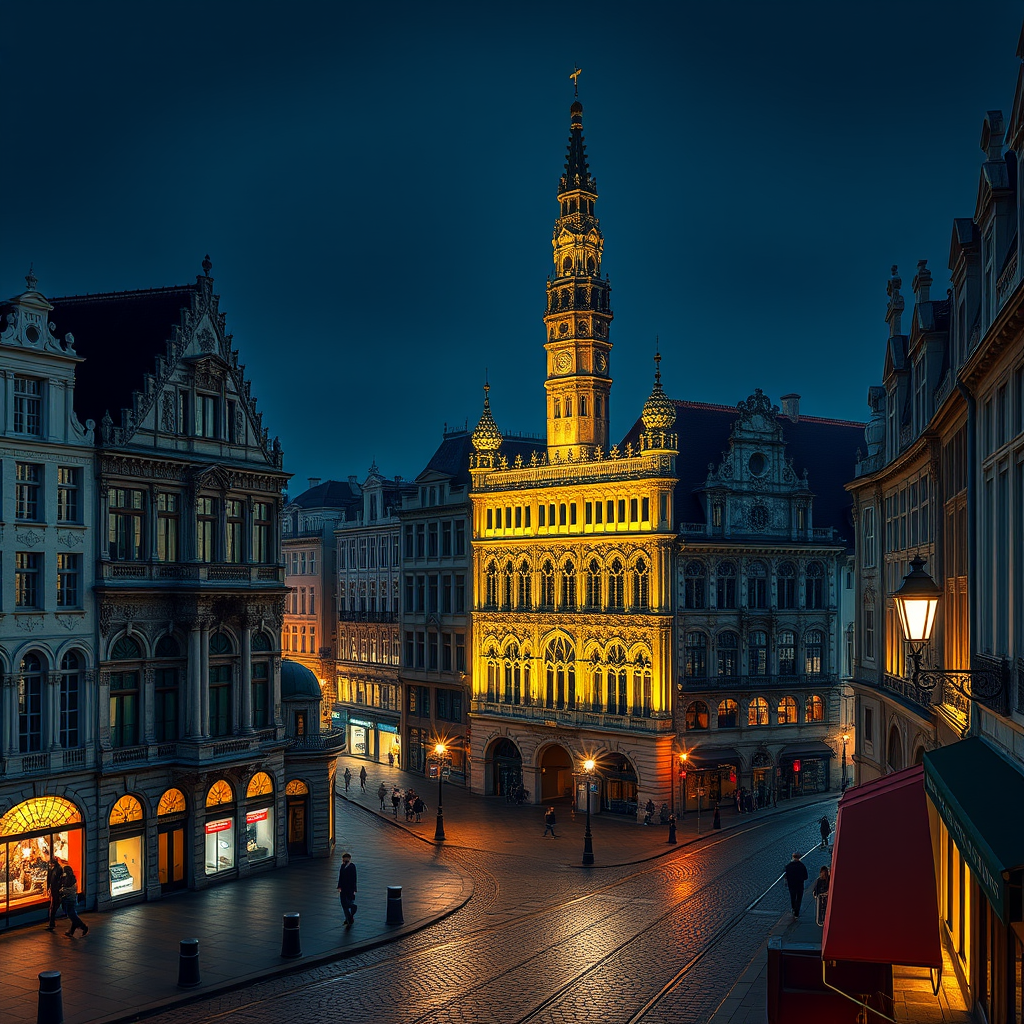

In [ ]:
from smolagents import Tool, CodeAgent, InferenceClientModel
from huggingface_hub import InferenceClient

class TextToImageTool(Tool):
    name = "image_generator"
    description = (
        "Generates an image from a text description. "
        "Add details like 'high-res, photorealistic' to improve quality."
    )
    inputs = {
        "prompt": {
            "type": "string",
            "description": "A detailed description of the image to generate."
        }
    }
    output_type = "image"

    def __init__(self):
        self.client = InferenceClient("black-forest-labs/FLUX.1-schnell", api_key="...")
        self.is_initialized = True

    def forward(self, prompt: str):
        return self.client.text_to_image(prompt)

text_to_image_tool = TextToImageTool()

agent = CodeAgent(tools=[text_to_image_tool], model=model)
result = agent.run("Generate a high-res photorealistic image of Brussels by night")
result  # In a notebook, this displays the image inline

#### Exercise 4.1 — Your own image prompt

Replace the Brussels prompt with a scene of your choice and re-run. Try adding descriptive style keywords to the prompt (e.g. `"watercolour painting"`, `"drone shot"`, `"golden hour lighting"`) and observe how it changes the result.

In [ ]:
# Your code here


### 4.2 Document retrieval (RAG) tool

A retrieval tool searches a collection of documents and returns relevant passages as a string. Here we use a BM25 keyword index over a small set of hand-written facts about the **ALGO-LIT** project — *Algorithmic Literacy for Effective Transparency in the EU* — a real research project run by [FARI](https://www.fari.brussels/research-and-innovation/project/algo-lit).

**Step 1 — Install dependencies**

In [ ]:
!pip install --quiet smolagents langchain_community rank_bm25

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.1/515.1 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 4.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.
transformers 5.0.0 requires huggingface-hub<2.0,>=1.3.0, but you have huggingface-hub 0.36.2 which is incompatible.


**Step 2 — Prepare documents**

Each document is a single plain-sentence fact. In a real use case these sentences could come from reports, web pages, or a database.

In [ ]:
from langchain_core.documents import Document

raw_facts = [
    "ALGO-LIT stands for Algorithmic Literacy for Effective Transparency in the EU.",
    "ALGO-LIT is funded by the Erasmus+ initiative of the European Union.",
    "The project runs from December 1, 2024 to November 30, 2027.",
    "FARI – AI for the Common Good Institute (VUB & ULB) is the Belgian partner and project lead.",
    "Datactivist, based in France, is a partner responsible for scientific direction.",
    "La Mednum, based in France, is a partner co-developing community tools.",
    "Waag Futurelab, based in the Netherlands, is a partner managing EU-wide workshops.",
    "ALGO-LIT aims to enhance algorithmic literacy among digital inclusion workers.",
    "Target audiences include workers at public digital spaces, libraries, and social services such as EPN, OCR, and CPAS.",
    "The project identifies professional needs, provides training, and co-develops tools with communities.",
    "FARI is responsible for defining mediation skills in EU competency frameworks.",
    "FARI oversees dissemination and assessment of all training materials.",
    "Alice Demaret is FARI's AI Impact Advisor on the project. Her email is alice.demaret@fari.brussels.",
    "Loup Cellard is the Scientific Director at Datactivist. Contact: algolit@datactivi.st.",
    "Bente Zwankhuizen is the Project Manager at Waag Futurelab. Contact: bente@waag.org.",
    "Quitterie de Marignan is the Project Manager at La Mednum. Contact: quitterie.demarignan@lamednum.coop.",
]

docs = [Document(page_content=fact) for fact in raw_facts]
print(f"Loaded {len(docs)} fact documents.")

Loaded 16 fact documents.


**Step 3 — Build the retriever tool and run the agent**

In [ ]:
from smolagents import Tool
from langchain_community.retrievers import BM25Retriever

class AlgoLitRetrieverTool(Tool):
    name = "algolit_retriever"
    description = (
        "Retrieves facts about the ALGO-LIT project "
        "(partners, funding, goals, contacts, timeline)."
    )
    inputs = {
        "query": {
            "type": "string",
            "description": "A question or keyword about the ALGO-LIT project."
        }
    }
    output_type = "string"

    def __init__(self, docs):
        self.is_initialized = False          # will be set True by super().__init__()
        self.retriever = BM25Retriever.from_documents(docs)

    def forward(self, query: str) -> str:
        results = self.retriever.invoke(query)
        if results:
            return "\n".join(doc.page_content for doc in results[:3])
        return "No matching information found."

algolit_tool = AlgoLitRetrieverTool(docs)

agent = CodeAgent(tools=[algolit_tool], model=model, verbosity_level=2)
result = agent.run("Who should I contact at Waag Futurelab for the ALGO-LIT project?")
print(result)

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Who should I contact at Waag Futurelab for the ALGO-LIT project?                                                │
│                                                                                                                 │
╰─ InferenceClientModel - Qwen/Qwen3.5-9B ────────────────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Output message of the LLM: ────────────────────────────────────────────────────────────────────────────────────────
Thought: I need to find contact information for the ALGO-LIT project at Waag Futurelab. I'll use the               
`algolit_retriever` function to query for contact information.                                                     
<code>                                                                                                             
contacts = algolit_retriever(query="contact")                                                                      
print(contacts)                                                                                                    

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  contacts = algolit_retriever(query="contact")                                                                    
  print(contacts)                                                                                                  
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Execution logs:
Quitterie de Marignan is the Project Manager at La Mednum. Contact: quitterie.demarignan@lamednum.coop.
Bente Zwankhuizen is the Project Manager at Waag Futurelab. Contact: bente@waag.org.
Loup Cellard is the Scientific Director at Datactivist. Contact: algolit@datactivi.st.

Out: None

...

Output message of the LLM: ────────────────────────────────────────────────────────────────────────────────────────
Thought: The algolit_retriever returned contact information. I can see that Bente Zwankhuizen is the Project       
Manager at Waag Futurelab, with contact email bente@waag.org. This is the contact person for the ALGO-LIT project  
at Waag Futurelab.                                                                                                 
<code>                                                                                                             
final_answer("Bente Zwankhuizen")                                                                                  

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  final_answer("Bente Zwankhuizen")                                                                                
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer: Bente Zwankhuizen

[Step 2: Duration 10.62 seconds| Input tokens: 4,641 | Output tokens: 320]

Bente Zwankhuizen


#### Exercise 4.2a — Extend the knowledge base

Add at least 3 more facts to `raw_facts`. You can look up the [FARI project page](https://www.fari.brussels/research-and-innovation/project/algo-lit) or invent plausible details (e.g. about outputs, website, or training methodology). Rebuild `docs` and `algolit_tool`, then write a query that specifically targets one of your new facts.

In [ ]:
# Your code here — add facts, rebuild docs and algolit_tool, run agent


#### Exercise 4.2b — Test the limits

Ask the agent: `"What programming language does ALGO-LIT use?"` — a question the knowledge base cannot answer. Does the agent admit it doesn't know, or does it hallucinate an answer?

In [ ]:
result = agent.run("What programming language does ALGO-LIT use?")
print(result)

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ What programming language does ALGO-LIT use?                                                                    │
│                                                                                                                 │
╰─ InferenceClientModel - Qwen/Qwen3.5-9B ────────────────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Output message of the LLM: ────────────────────────────────────────────────────────────────────────────────────────
Thought: I need to find out what programming language ALGO-LIT uses. I have access to the `algolit_retriever`      
function which can retrieve facts about the ALGO-LIT project. I'll query it to find information about the          
programming language used.                                                                                         
                                                                                                                   
<code>                                                                                                             
result = algolit_retriever(query="programming language")                                                           
print(result)                                                                                                      

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  result = algolit_retriever(query="programming language")                                                         
  print(result)                                                                                                    
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Execution logs:
Quitterie de Marignan is the Project Manager at La Mednum. Contact: quitterie.demarignan@lamednum.coop.
Bente Zwankhuizen is the Project Manager at Waag Futurelab. Contact: bente@waag.org.
Loup Cellard is the Scientific Director at Datactivist. Contact: algolit@datactivi.st.

Out: None

...

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  result = algolit_retriever(query="datactivist waag la mednum")                                                   
  print(result)                                                                                                    
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Execution logs:
Quitterie de Marignan is the Project Manager at La Mednum. Contact: quitterie.demarignan@lamednum.coop.
Bente Zwankhuizen is the Project Manager at Waag Futurelab. Contact: bente@waag.org.
Loup Cellard is the Scientific Director at Datactivist. Contact: algolit@datactivi.st.

Out: None

[Step 20: Duration 3.91 seconds| Input tokens: 80,474 | Output tokens: 2,199]

Reached max steps.

[Step 21: Duration 41.77 seconds| Input tokens: 84,280 | Output tokens: 4,247]

### 4.3 Web search tool

`smolagents` ships with a built-in `DuckDuckGoSearchTool` that performs live web searches with no API key required. It is the quickest way to give your agent access to up-to-date information it was not trained on.

In [ ]:
!pip install --quiet duckduckgo_search ddgs markdownify requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 57.7 MB/s eta 0:00:00


In [ ]:
from smolagents import DuckDuckGoSearchTool, CodeAgent

search_tool = DuckDuckGoSearchTool()

agent = CodeAgent(tools=[search_tool], model=model, verbosity_level=2)
result = agent.run("What is the ALGO-LIT project by FARI Brussels?")
print(result)

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ What is the ALGO-LIT project by FARI Brussels?                                                                  │
│                                                                                                                 │
╰─ InferenceClientModel - Qwen/Qwen3.5-9B ────────────────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Output message of the LLM: ────────────────────────────────────────────────────────────────────────────────────────
Thought: I need to search for information about the ALGO-LIT project by FARI Brussels. I'll use web_search to find 
relevant information.                                                                                              
<code>                                                                                                             
result = web_search(query="ALGO-LIT project FARI Brussels")                                                        
print(result)                                                                                                      

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  result = web_search(query="ALGO-LIT project FARI Brussels")                                                      
  print(result)                                                                                                    
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Execution logs:
## Search Results

[ALGO-LIT (Erasmus+ Project) - Fari Institute - 
fari.brussels](https://www.fari.brussels/research-and-innovation/project/algo-lit)
FARI is a part of the ALGO-LIT project, an Erasmus+ initiative to enhances algorithmic literacy and support 
citizens in algorithm-driven systems.

[Atelier ALGO-LIT Tickets, Tuesday, June 16-Wednesday, June 17 | 
Eventbrite](https://www.eventbrite.be/e/atelier-algo-lit-tickets-1987677315357)
Eventbrite - FARI - AI for the Common Good Institute Brussels presents Atelier ALGO-LIT - Tuesday, June 16, 2026 at
Cantersteen 12, Bruxelles, Bruxelles. Find event and ticket information.

[FARI is excited to announce the launch of the ALGO-LIT project in 
...](https://www.linkedin.com/posts/fari-ai-for-the-common-good-institute_fari-is-excited-to-announce-the-launch-of
-activity-7252619377764626432-WoCK)
This project is led by Datactivist, La Mednum, FARI - AI for the Common Good Institute, and Waag Futurelab. Stay 
tuned for more updates as we approach the project start in December!

[Boosting Algorithmic Literacy Across Europe with ALGO-LIT - Fari 
Institute](https://www.fari.brussels/news-and-media-article/algolit-project)
FARI joins the ALGO-LIT project to advance algorithmic literacy and digital inclusion across Europe. The initiative
supports digital inclusion workers in helping citizens navigate AI-driven systems through training, co-creation, 
and ethical mediation.

[Launch event - ALGOLIT (Algorithm literacy for effective transparency 
...](https://my.weezevent.com/launch-event-algolit-algorithm-literacy-for-effective-transparency-in-the-eu)
ENGLISH (+ DUTCH BELOW) Launch of the research-action project ALGOLIT (Developing algorithmic literacy for greater 
transparency in the EU) on 26 February 2025 from 10am to 12pm in the BeCentral Boardroom (Brussels). The 
cooperatives Datactivist and La Mednum (France) and the research centres FARI (Brussels) et Waag (Amsterdam) invite
you to the launch event of the ALGOLIT project, which has ...

[FARI - AI for the Common Good Institute Brussels: Overview - 
urbanNext](https://urbannext.net/fari-ai-for-the-common-good-institute-brussels-overview/)
It also introduces flagship European projects—such as CitCom.ai, DIGISET, LIBRA.I., MultiRoofs, ALGO-LIT, AI4GOV-X,
and RADAR-AIM—showcasing how FARI integrates innovation, ethics, and citizen engagement in shaping technology for 
social benefit.

[FARI - AI for the Common Good Institute on LinkedIn: #datawalk # 
...](https://www.linkedin.com/posts/fari-ai-for-the-common-good-institute_datawalk-digitalweek2023-data-activity-71
17157432249720832-Goxi)
FARI is excited to announce the launch of the ALGO-LIT project in December! The goal is to help digital inclusion 
actors better understand algorithms. This project also focuses on empowering ...

[FARI AI for the Common Good Institute - Brussels Capital 
Region](https://commission.europa.eu/projects/fari-ai-common-good-institute-brussels-capital-region_en?prefLang=sl)
As part of the EUR 9.91 million budget provided by the RRF, in 2022 FARI completed 4 pilot projects with AI in 
order to foster administrative simplification, animal welfare and employment, and to develop an AI strategy for 
Brussels.

[FARI | Andrée Geulen asbl-vzw](https://ulb-vub.be/fr/fari)
FARI est un institut universitaire à but non lucratif, engagé pour le bien commun et dédié à l'IA, aux données et à
la robotique. Nous sommes le fruit d'une initiative commune portée par deux universités bruxelloises (la VUB et 
l'ULB) qui ont réuni leur expertise interdisciplinaire à travers 10 groupes de recherche sur l'IA, les ...

[Search - Erasmus+](https://erasmus-plus.ec.europa.eu/projects/search/details/2024-1-FR01-KA220-ADU-000250548)
The ALGO-LIT project aims at at improving the algorithmic literacy skills of more than 5,000 digital mediators to 
better support citizens, including the most vulnerable, to understand algorithmic-based decisions and effectively 
exercise th

...

Output message of the LLM: ────────────────────────────────────────────────────────────────────────────────────────
Thought: I have found comprehensive information about the ALGO-LIT project by FARI Brussels. Let me compile this   
information and provide a final answer.                                                                            
<code>                                                                                                             
final_answer("The ALGO-LIT project (Algorithm literacy for effective transparency in the EU) by FARI Brussels is an
Erasmus+ initiative that aims to enhance algorithmic literacy across Europe. Led by FARI - AI for the Common Good  
Institute Brussels along with partners Datactivist, La Mednum, and Waag Futurelab, the project focuses on          
supporting digital inclusion workers to better understand and help citizens navigate AI-driven systems. The goal is
to improve the algorithmic literacy skills of more than 5,000 digital mediators to help citizens, especially       
vulnerable ones, understand algorithmic-based decisions, effectively exercise their right to transparency and      
information, through training, co-creation, and ethical mediation.")                                               

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  final_answer("The ALGO-LIT project (Algorithm literacy for effective transparency in the EU) by FARI Brussels    
  is an Erasmus+ initiative that aims to enhance algorithmic literacy across Europe. Led by FARI - AI for the      
  Common Good Institute Brussels along with partners Datactivist, La Mednum, and Waag Futurelab, the project       
  focuses on supporting digital inclusion workers to better understand and help citizens navigate AI-driven        
  systems. The goal is to improve the algorithmic literacy skills of more than 5,000 digital mediators to help     
  citizens, especially vulnerable ones, understand algorithmic-based decisions, effectively exercise their right   
  to transparency and information, through training, co-creation, and ethical mediation.")                         
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer: The ALGO-LIT project (Algorithm literacy for effective transparency in the EU) by FARI Brussels is an
Erasmus+ initiative that aims to enhance algorithmic literacy across Europe. Led by FARI - AI for the Common Good 
Institute Brussels along with partners Datactivist, La Mednum, and Waag Futurelab, the project focuses on 
supporting digital inclusion workers to better understand and help citizens navigate AI-driven systems. The goal is
to improve the algorithmic literacy skills of more than 5,000 digital mediators to help citizens, especially 
vulnerable ones, understand algorithmic-based decisions, effectively exercise their right to transparency and 
information, through training, co-creation, and ethical mediation.

[Step 2: Duration 7.18 seconds| Input tokens: 5,595 | Output tokens: 493]

The ALGO-LIT project (Algorithm literacy for effective transparency in the EU) by FARI Brussels is an Erasmus+ initiative that aims to enhance algorithmic literacy across Europe. Led by FARI - AI for the Common Good Institute Brussels along with partners Datactivist, La Mednum, and Waag Futurelab, the project focuses on supporting digital inclusion workers to better understand and help citizens navigate AI-driven systems. The goal is to improve the algorithmic literacy skills of more than 5,000 digital mediators to help citizens, especially vulnerable ones, understand algorithmic-based decisions, effectively exercise their right to transparency and information, through training, co-creation, and ethical mediation.


You can also pair the search tool with `VisitWebpageTool` so the agent can follow links and read full pages.

In [ ]:
from smolagents import DuckDuckGoSearchTool, VisitWebpageTool, CodeAgent

agent = CodeAgent(
    tools=[DuckDuckGoSearchTool(), VisitWebpageTool()],
    model=model,
    verbosity_level=2,
)
result = agent.run(
    "Find the ALGO-LIT project page on fari.brussels and summarise its goals."
)
print(result)

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Find the ALGO-LIT project page on fari.brussels and summarise its goals.                                        │
│                                                                                                                 │
╰─ InferenceClientModel - Qwen/Qwen3.5-9B ────────────────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Output message of the LLM: ────────────────────────────────────────────────────────────────────────────────────────
Thought: I need to find the ALGO-LIT project page on fari.brussels and summarize its goals. I'll start by searching
for "fari.brussels ALGO-LIT project" to find the relevant page.                                                    
<code>                                                                                                             
pages = web_search(query="fari.brussels ALGO-LIT project")                                                         
print(pages)                                                                                                       

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  pages = web_search(query="fari.brussels ALGO-LIT project")                                                       
  print(pages)                                                                                                     
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Execution logs:
## Search Results

[ALGO-LIT (Erasmus+ Project) - Fari Institute - 
fari.brussels](https://www.fari.brussels/research-and-innovation/project/algo-lit)
FARI is a part of the ALGO-LIT project, an Erasmus+ initiative to enhances algorithmic literacy and support 
citizens in algorithm-driven systems.

[Atelier ALGO-LIT Tickets, Tuesday, June 16-Wednesday, June 17 | 
Eventbrite](https://www.eventbrite.be/e/atelier-algo-lit-tickets-1987677315357)
Eventbrite - FARI - AI for the Common Good Institute Brussels presents Atelier ALGO-LIT - Tuesday, June 16, 2026 at
Cantersteen 12, Bruxelles, Bruxelles. Find event and ticket information.

[FARI is excited to announce the launch of the ALGO-LIT project in 
...](https://www.linkedin.com/posts/fari-ai-for-the-common-good-institute_fari-is-excited-to-announce-the-launch-of
-activity-7252619377764626432-WoCK)
This project is led by Datactivist, La Mednum, FARI - AI for the Common Good Institute, and Waag Futurelab. Stay 
tuned for more updates as we approach the project start in December!

[Boosting Algorithmic Literacy Across Europe with ALGO-LIT - Fari 
Institute](https://www.fari.brussels/news-and-media-article/algolit-project)
FARI joins the ALGO-LIT project to advance algorithmic literacy and digital inclusion across Europe. The initiative
supports digital inclusion workers in helping citizens navigate AI-driven systems through training, co-creation, 
and ethical mediation.

[Launch event - ALGOLIT (Algorithm literacy for effective transparency 
...](https://my.weezevent.com/launch-event-algolit-algorithm-literacy-for-effective-transparency-in-the-eu)
ENGLISH (+ DUTCH BELOW) Launch of the research-action project ALGOLIT (Developing algorithmic literacy for greater 
transparency in the EU) on 26 February 2025 from 10am to 12pm in the BeCentral Boardroom (Brussels). The 
cooperatives Datactivist and La Mednum (France) and the research centres FARI (Brussels) et Waag (Amsterdam) invite
you to the launch event of the ALGOLIT project, which has ...

[Women in Digital 2025 | FARI - AI for the Common Good 
Institute](https://www.linkedin.com/posts/fari-ai-for-the-common-good-institute_how-can-europe-build-an-ai-ecosyste
m-that-activity-7414621861742936064-RqVY)
From gendered innovations in research and governance to concrete citizen-driven projects like ALGO-LIT, FARI 
demonstrates how inclusion can be translated from principles into action; starting in ...

[FARI - AI for the Common Good Institute's Post - 
LinkedIn](https://www.linkedin.com/posts/fari-ai-for-the-common-good-institute_algorithmicliteracy-digitalinclusion
-activity-7332707104853590016-sz7T)
Help shape the future of algorithmic literacy in Europe! 🚨 FARI - AI for the Common Good Institute has joined the 
ALGO-LIT project, an Erasmus Plus initiative which equips digital inclusion ...

[FARI | Andrée Geulen asbl-vzw](https://www.ulb-vub.be/en/fari)
FARI is a non-profit university institute on AI, data and robotics focused on the Common Good. We are jointly 
initiated by two Brussels universities (VUB & ULB) - uniting the interdisciplinary expertise across 10 research 
groups on AI, data, robotics, social sciences, ethics, and law.

[FARI - AI for the Common Good Institute Brussels: Overview - 
urbanNext](https://urbannext.net/fari-ai-for-the-common-good-institute-brussels-overview/)
This document presents an overview of FARI - AI for the Common Good Institute Brussels, a non-profit initiative 
founded by VUB and ULB. It outlines the institute's mission to promote sustainable and trustworthy applications of 
AI, data, and robotics across public and urban domains such as health, mobility, climate, and inclusive society.

[PDF Organized by - urbannext.net](https://urbannext.net/wp-content/uploads/2025/12/FARI-Overview.pdf)
FARIis a non-profit university institute on AI, data and robotics focused on the Common Good. We are jointly 
initiated by two Brussels universities (VUB & ULB) - uniting the interdisciplinary expert

...

Output message of the LLM: ────────────────────────────────────────────────────────────────────────────────────────
Thought: I have successfully retrieved the ALGO-LIT project page from fari.brussels and extracted the key          
information about its goals. Now I will provide the final summary as the answer.                                   
<code>                                                                                                             
final_answer("""The ALGO-LIT project is an Erasmus+ initiative (2024-2027) involving 4 partners: Datactivist and La
Mednum from France, Waag Futurelab from the Netherlands, and FARI from Belgium.                                    
                                                                                                                   
**Key Goals:**                                                                                                     
1. **Enhance algorithmic literacy** among digital inclusion workers (Espaces Publics Numériques, Openbare          
Computerruimte, Libraries, CPAS) and rights advocates                                                              
2. **Support citizens** in navigating algorithm-driven systems (e.g., AI chatbots, tax forms, public service       
decisions)                                                                                                         
3. **Provide training and share practices** through mapping needs and co-developing tools with the community       
4. **Promote algorithmic transparency** through mediation - communication, explanation, and community-building     
5. **Integrate algorithmic literacy into broader EU frameworks** through training, knowledge-sharing, and          
institutional advocacy                                                                                             
6. **Foster communities of practice** around complex algorithms to empower both professionals and citizens         
                                                                                                                   
**Core Philosophy:** Beyond open code, true transparency requires mediation and structured guidance to make        
algorithms understandable and actionable for citizens and professionals alike.**""")                               

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  final_answer("""The ALGO-LIT project is an Erasmus+ initiative (2024-2027) involving 4 partners: Datactivist     
  and La Mednum from France, Waag Futurelab from the Netherlands, and FARI from Belgium.                           
                                                                                                                   
  **Key Goals:**                                                                                                   
  1. **Enhance algorithmic literacy** among digital inclusion workers (Espaces Publics Numériques, Openbare        
  Computerruimte, Libraries, CPAS) and rights advocates                                                            
  2. **Support citizens** in navigating algorithm-driven systems (e.g., AI chatbots, tax forms, public service     
  decisions)                                                                                                       
  3. **Provide training and share practices** through mapping needs and co-developing tools with the community     
  4. **Promote algorithmic transparency** through mediation - communication, explanation, and community-building   
  5. **Integrate algorithmic literacy into broader EU frameworks** through training, knowledge-sharing, and        
  institutional advocacy                                                                                           
  6. **Foster communities of practice** around complex algorithms to empower both professionals and citizens       
                                                                                                                   
  **Core Philosophy:** Beyond open code, true transparency requires mediation and structured guidance to make      
  algorithms understandable and actionable for citizens and professionals alike.**""")                             
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer: The ALGO-LIT project is an Erasmus+ initiative (2024-2027) involving 4 partners: Datactivist and La 
Mednum from France, Waag Futurelab from the Netherlands, and FARI from Belgium.

**Key Goals:**
1. **Enhance algorithmic literacy** among digital inclusion workers (Espaces Publics Numériques, Openbare 
Computerruimte, Libraries, CPAS) and rights advocates
2. **Support citizens** in navigating algorithm-driven systems (e.g., AI chatbots, tax forms, public service 
decisions)
3. **Provide training and share practices** through mapping needs and co-developing tools with the community
4. **Promote algorithmic transparency** through mediation - communication, explanation, and community-building
5. **Integrate algorithmic literacy into broader EU frameworks** through training, knowledge-sharing, and 
institutional advocacy
6. **Foster communities of practice** around complex algorithms to empower both professionals and citizens

**Core Philosophy:** Beyond open code, true transparency requires mediation and structured guidance to make 
algorithms understandable and actionable for citizens and professionals alike.**

[Step 4: Duration 3.80 seconds| Input tokens: 19,173 | Output tokens: 1,132]

The ALGO-LIT project is an Erasmus+ initiative (2024-2027) involving 4 partners: Datactivist and La Mednum from France, Waag Futurelab from the Netherlands, and FARI from Belgium.

**Key Goals:**
1. **Enhance algorithmic literacy** among digital inclusion workers (Espaces Publics Numériques, Openbare Computerruimte, Libraries, CPAS) and rights advocates
2. **Support citizens** in navigating algorithm-driven systems (e.g., AI chatbots, tax forms, public service decisions)
3. **Provide training and share practices** through mapping needs and co-developing tools with the community
4. **Promote algorithmic transparency** through mediation - communication, explanation, and community-building
5. **Integrate algorithmic literacy into broader EU frameworks** through training, knowledge-sharing, and institutional advocacy
6. **Foster communities of practice** around complex algorithms to empower both professionals and citizens

**Core Philosophy:** Beyond open code, true transparency requires m

#### Combining web search with a local knowledge base

You can give the agent **both** the `algolit_tool` from section 4.2 and the web search tool. The agent will decide which to call depending on the question. The first part of the question below is in the local knowledge base; the second requires the web.

In [ ]:
agent = CodeAgent(
    tools=[algolit_tool, DuckDuckGoSearchTool()],
    model=model,
    verbosity_level=2,
)
result = agent.run(
    "Who are the partners of ALGO-LIT, and what other EU projects does Waag Futurelab participate in?"
)
print(result)

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Who are the partners of ALGO-LIT, and what other EU projects does Waag Futurelab participate in?                │
│                                                                                                                 │
╰─ InferenceClientModel - Qwen/Qwen3.5-9B ────────────────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Output message of the LLM: ────────────────────────────────────────────────────────────────────────────────────────
Thought: I need to find information about ALGO-LIT partners and Waag Futurelab's EU project participation. I'll    
start by using the `algolit_retriever` tool to get information about ALGO-LIT partners.                            
<code>                                                                                                             
partners_info = algolit_retriever(query="partners")                                                                
print(partners_info)                                                                                               

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  partners_info = algolit_retriever(query="partners")                                                              
  print(partners_info)                                                                                             
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Execution logs:
Quitterie de Marignan is the Project Manager at La Mednum. Contact: quitterie.demarignan@lamednum.coop.
Bente Zwankhuizen is the Project Manager at Waag Futurelab. Contact: bente@waag.org.
Loup Cellard is the Scientific Director at Datactivist. Contact: algolit@datactivi.st.

Out: None

...

Output message of the LLM: ────────────────────────────────────────────────────────────────────────────────────────
Thought: I now have enough information to answer the question. From the web search results, I can see:             
                                                                                                                   
ALGO-LIT Partners:                                                                                                 
- Datactivist                                                                                                      
- La Mednum (France)                                                                                               
- Waag Futurelab (Netherlands)                                                                                     
- FARI from Belgium                                                                                                
                                                                                                                   
Waag Futurelab's other EU projects:                                                                                
1. European Digital Deal project                                                                                   
2. Hamlet project                                                                                                  
3. Future Internet Lab (with TNO)                                                                                  
4. Critical ChangeLab                                                                                              
                                                                                                                   
Let me compile this into a final answer.                                                                           
<code>                                                                                                             
final_answer("""                                                                                                   
ALGO-LIT Partners:                                                                                                 
- Datactivist                                                                                                      
- La Mednum (France)                                                                                               
- Waag Futurelab (Netherlands)                                                                                     
- FARI (Belgium)                                                                                                   
                                                                                                                   
Waag Futurelab's other EU projects:                                                                                
1. European Digital Deal                                                                                           
2. Hamlet project                                                                                                  
3. Future Internet Lab (with TNO)                                                                                  
4. Critical ChangeLab                                                                                              
""")                                                                                                               

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  final_answer("""                                                                                                 
  ALGO-LIT Partners:                                                                                               
  - Datactivist                                                                                                    
  - La Mednum (France)                                                                                             
  - Waag Futurelab (Netherlands)                                                                                   
  - FARI (Belgium)                                                                                                 
                                                                                                                   
  Waag Futurelab's other EU projects:                                                                              
  1. European Digital Deal                                                                                         
  2. Hamlet project                                                                                                
  3. Future Internet Lab (with TNO)                                                                                
  4. Critical ChangeLab                                                                                            
  """)                                                                                                             
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer: 
ALGO-LIT Partners:
- Datactivist
- La Mednum (France)
- Waag Futurelab (Netherlands)
- FARI (Belgium)

Waag Futurelab's other EU projects:
1. European Digital Deal
2. Hamlet project
3. Future Internet Lab (with TNO)
4. Critical ChangeLab

[Step 10: Duration 9.67 seconds| Input tokens: 37,543 | Output tokens: 1,801]


ALGO-LIT Partners:
- Datactivist
- La Mednum (France)
- Waag Futurelab (Netherlands)
- FARI (Belgium)

Waag Futurelab's other EU projects:
1. European Digital Deal
2. Hamlet project
3. Future Internet Lab (with TNO)
4. Critical ChangeLab



#### Exercise 4.3b — Multi-tool agent

Give the agent both `algolit_tool` and `DuckDuckGoSearchTool`. Ask it a question that requires both sources, for example:

```
"What is Alice Demaret's role in ALGO-LIT, and what has she recently published or presented?"
```

Watch the `verbosity_level=2` output carefully. Can you see the agent choosing between the two tools?

In [ ]:
# Your code here


**Question:** Web search gives the agent access to the whole internet. What risks does that introduce compared to a curated local knowledge base? Name at least two: one about reliability and one about privacy.

---
## Summary

| Concept | Key point |
|---|---|
| `@tool` decorator | Fastest way — reads type hints and docstring |
| `Tool` class | More control — use when setup or non-string output is needed |
| `CodeAgent` | Runs tools by generating and executing Python code |
| `verbosity_level=2` | Shows every reasoning step |
| `agent.write_memory_to_messages()` | Full conversation history |
| `agent.prompt_templates` | System prompt and other templates |
| `DuckDuckGoSearchTool` | Built-in live web search, no API key needed |
| `VisitWebpageTool` | Built-in tool to fetch and read a full web page |
